In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers timm scikit-learn matplotlib seaborn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 10


In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
train_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATASET_DIR, "val"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATASET_DIR, "test"), transform=transform)

class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def build_model(model_name):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=NUM_CLASSES
    )
    return model.to(device)


In [ ]:
def train_model(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_acc, val_acc = [], []
    train_loss, val_loss = [], []

    for epoch in range(EPOCHS):
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct / total)

        # Validation
        model.eval()
        correct, total, running_loss = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss.append(running_loss / len(val_loader))
        val_acc.append(correct / total)

        print(f"Epoch [{epoch+1}/{EPOCHS}] "
              f"Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

    return train_acc, val_acc, train_loss, val_loss


In [ ]:
def evaluate_model(model):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    error_rate = 1 - acc
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    cm = confusion_matrix(y_true, y_pred)

    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    TPR = np.mean(TP / (TP + FN))
    FPR = np.mean(FP / (FP + TN))
    TNR = np.mean(TN / (TN + FP))
    FNR = np.mean(FN / (FN + TP))

    return {
        "Accuracy": acc,
        "Error Rate": error_rate,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TPR": TPR,
        "FPR": FPR,
        "TNR": TNR,
        "FNR": FNR,
        "CM": cm,
        "y_true": y_true,
        "y_prob": y_prob
    }


In [ ]:
def plot_training(history, title):
    train_acc, val_acc, train_loss, val_loss = history

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()


In [ ]:
def plot_confusion(cm, title):
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:
def plot_roc_pr(y_true, y_prob, title):
    y_true_oh = np.eye(NUM_CLASSES)[y_true]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_prob[:, i])
        plt.plot(fpr, tpr)
    plt.title(f"{title} ROC")

    plt.subplot(1,2,2)
    for i in range(NUM_CLASSES):
        p, r, _ = precision_recall_curve(y_true_oh[:, i], y_prob[:, i])
        plt.plot(r, p)
    plt.title(f"{title} Precision-Recall")

    plt.show()



Training ViT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Epoch [1/10] Train Acc: 0.8674, Val Acc: 0.9026
Epoch [2/10] Train Acc: 0.9495, Val Acc: 0.8896
Epoch [3/10] Train Acc: 0.9520, Val Acc: 0.9221
Epoch [4/10] Train Acc: 0.9786, Val Acc: 0.9310
Epoch [5/10] Train Acc: 0.9789, Val Acc: 0.9196
Epoch [6/10] Train Acc: 0.9762, Val Acc: 0.9156
Epoch [7/10] Train Acc: 0.9812, Val Acc: 0.9310
Epoch [8/10] Train Acc: 0.9901, Val Acc: 0.9302
Epoch [9/10] Train Acc: 0.9894, Val Acc: 0.9278
Epoch [10/10] Train Acc: 0.9904, Val Acc: 0.9205


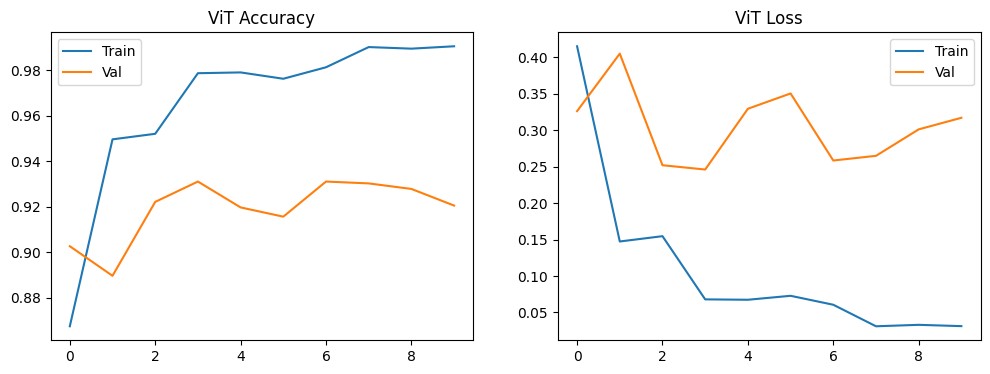

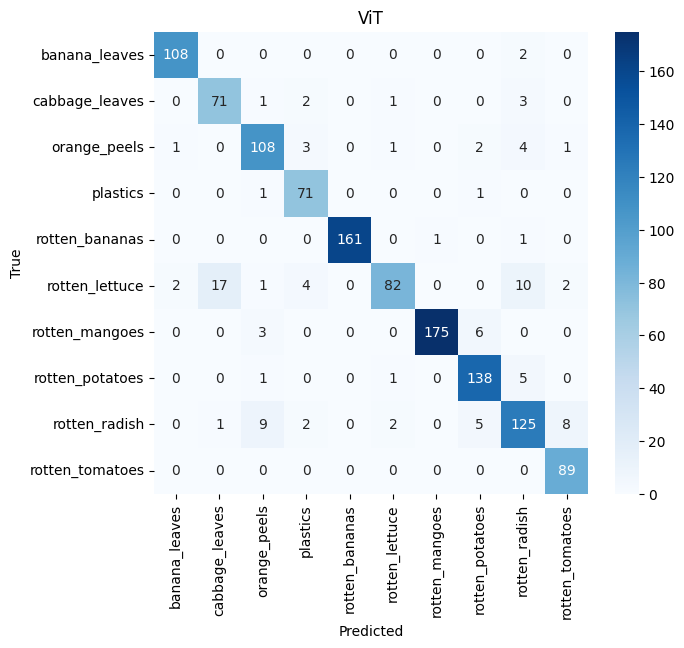

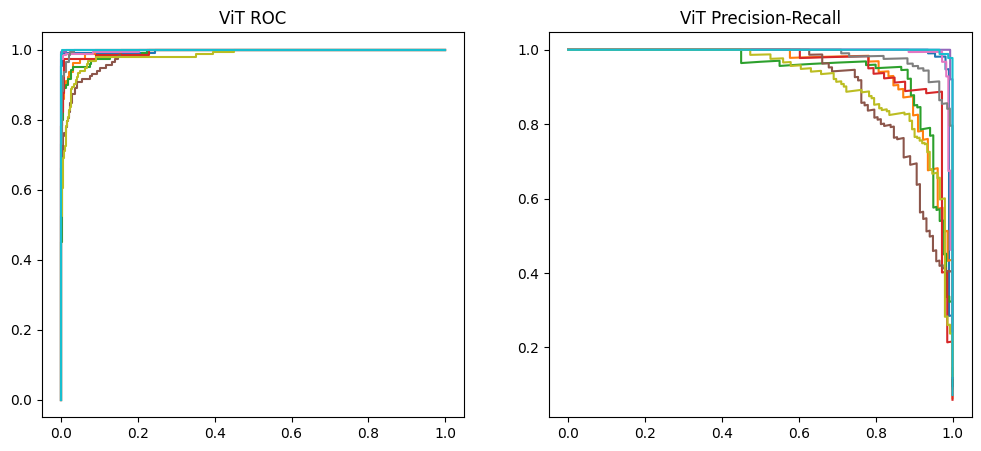


Training DeiT


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch [1/10] Train Acc: 0.8833, Val Acc: 0.9456
Epoch [2/10] Train Acc: 0.9850, Val Acc: 0.9383
Epoch [3/10] Train Acc: 0.9960, Val Acc: 0.9497
Epoch [4/10] Train Acc: 0.9967, Val Acc: 0.9472
Epoch [5/10] Train Acc: 0.9918, Val Acc: 0.9351
Epoch [6/10] Train Acc: 0.9863, Val Acc: 0.9489
Epoch [7/10] Train Acc: 0.9901, Val Acc: 0.9416
Epoch [8/10] Train Acc: 0.9974, Val Acc: 0.9261
Epoch [9/10] Train Acc: 0.9951, Val Acc: 0.9424
Epoch [10/10] Train Acc: 0.9953, Val Acc: 0.9334


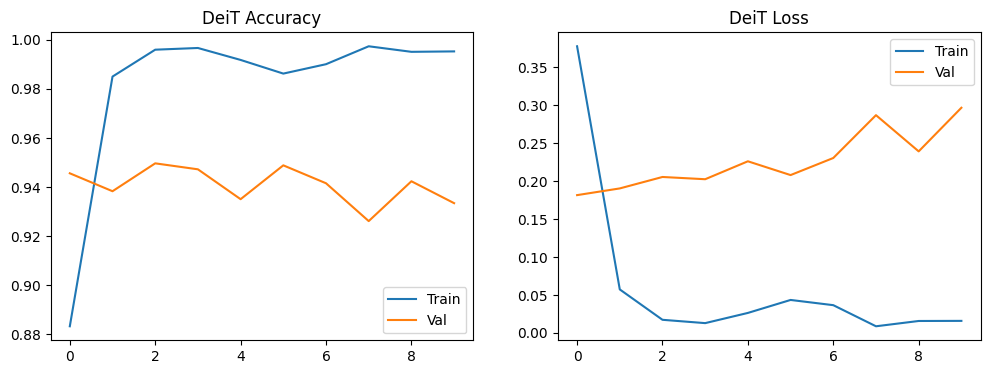

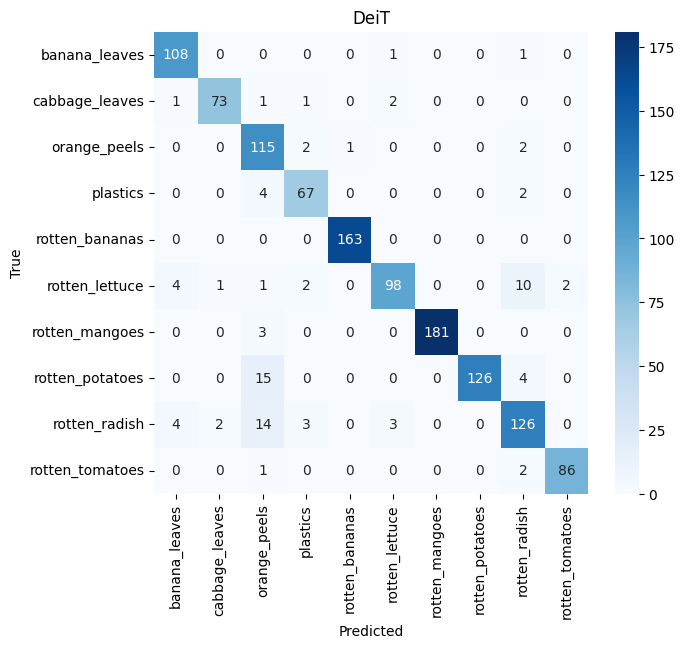

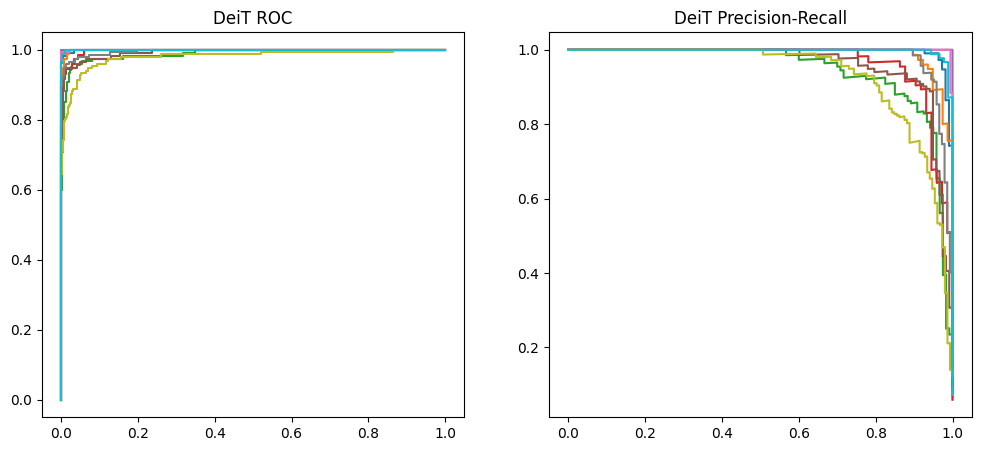


Training Swin


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Epoch [1/10] Train Acc: 0.8989, Val Acc: 0.9456
Epoch [2/10] Train Acc: 0.9682, Val Acc: 0.9619
Epoch [3/10] Train Acc: 0.9927, Val Acc: 0.9497
Epoch [4/10] Train Acc: 0.9889, Val Acc: 0.9505
Epoch [5/10] Train Acc: 0.9892, Val Acc: 0.9058
Epoch [6/10] Train Acc: 0.9854, Val Acc: 0.9602
Epoch [7/10] Train Acc: 0.9890, Val Acc: 0.9554
Epoch [8/10] Train Acc: 0.9923, Val Acc: 0.9513


In [ ]:
models = {
    "ViT": "vit_base_patch16_224",
    "DeiT": "deit_base_patch16_224",
    "Swin": "swin_base_patch4_window7_224"
}

results = {}

for name, model_id in models.items():
    print(f"\nTraining {name}")
    model = build_model(model_id)
    history = train_model(model)

    torch.save(model.state_dict(), f"{name}.pth")

    metrics = evaluate_model(model)
    results[name] = metrics

    plot_training(history, name)
    plot_confusion(metrics["CM"], name)
    plot_roc_pr(metrics["y_true"], metrics["y_prob"], name)




Training Swin


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Epoch [1/10] Train Acc: 0.8895, Val Acc: 0.9505
Epoch [2/10] Train Acc: 0.9709, Val Acc: 0.9481
Epoch [3/10] Train Acc: 0.9824, Val Acc: 0.9497
Epoch [4/10] Train Acc: 0.9863, Val Acc: 0.9610
Epoch [5/10] Train Acc: 0.9904, Val Acc: 0.9627
Epoch [6/10] Train Acc: 0.9876, Val Acc: 0.9570
Epoch [7/10] Train Acc: 0.9934, Val Acc: 0.9554
Epoch [8/10] Train Acc: 0.9929, Val Acc: 0.9416
Epoch [9/10] Train Acc: 0.9901, Val Acc: 0.9505
Epoch [10/10] Train Acc: 0.9916, Val Acc: 0.9529


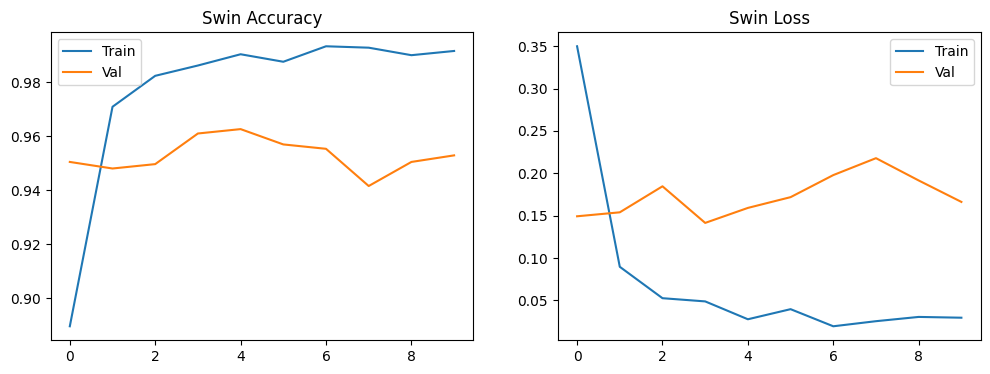

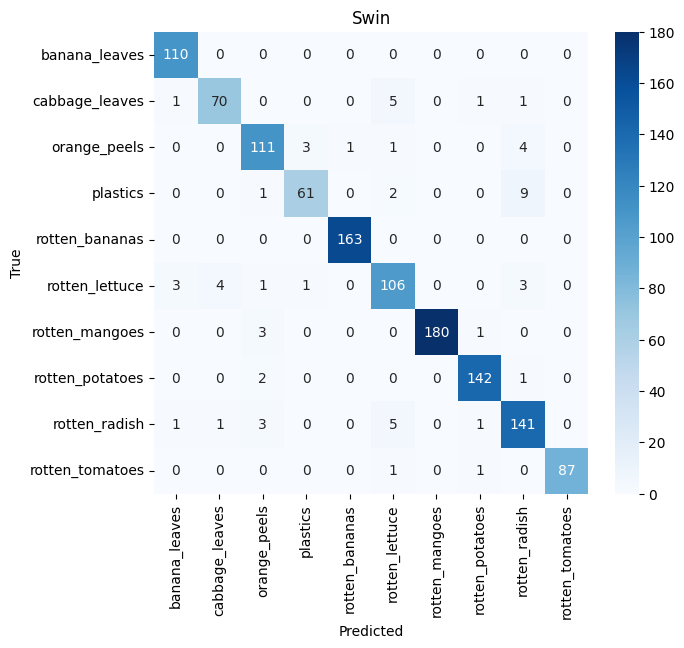

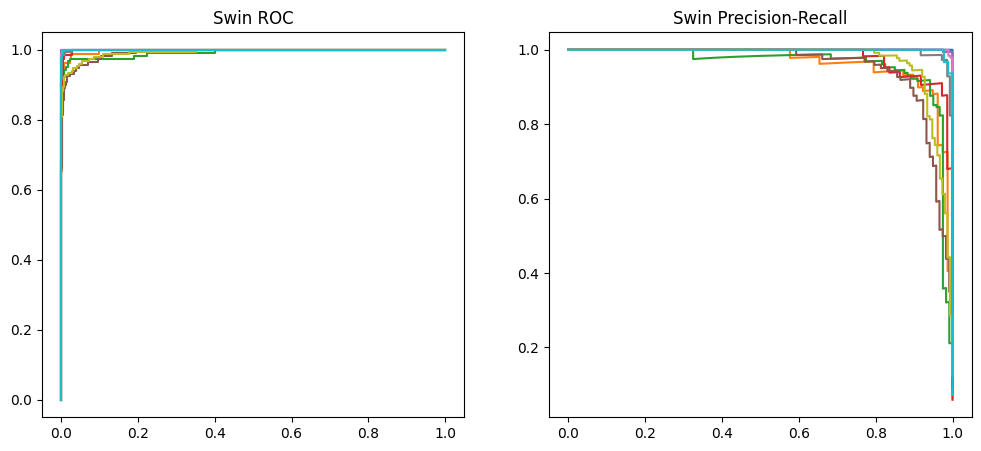

In [ ]:
models = {

    "Swin": "swin_base_patch4_window7_224"
}

results = {}

for name, model_id in models.items():
    print(f"\nTraining {name}")
    model = build_model(model_id)
    history = train_model(model)

    torch.save(model.state_dict(), f"{name}.pth")

    metrics = evaluate_model(model)
    results[name] = metrics

    plot_training(history, name)
    plot_confusion(metrics["CM"], name)
    plot_roc_pr(metrics["y_true"], metrics["y_prob"], name)



In [ ]:
import json
import numpy as np

# Assuming 'results' dictionary already contains the metrics for 'Swin'
if 'Swin' in results:
    swin_metrics = results['Swin']

    # Convert numpy types to native Python types for JSON serialization
    serializable_swin_metrics = {
        k: (v.tolist() if isinstance(v, np.ndarray) else v.item() if isinstance(v, np.generic) else v)
        for k, v in swin_metrics.items() if k not in ["CM", "y_true", "y_prob"]
    }

    with open('swin_training_metrics.json', 'w') as f:
        json.dump(serializable_swin_metrics, f, indent=4)
    print("Swin training metrics saved to swin_training_metrics.json")
else:
    print("Swin model results not found in the 'results' dictionary.")

print("The Swin model file (Swin.pth) was already saved during its training.")

Swin training metrics saved to swin_training_metrics.json
The Swin model file (Swin.pth) was already saved during its training.


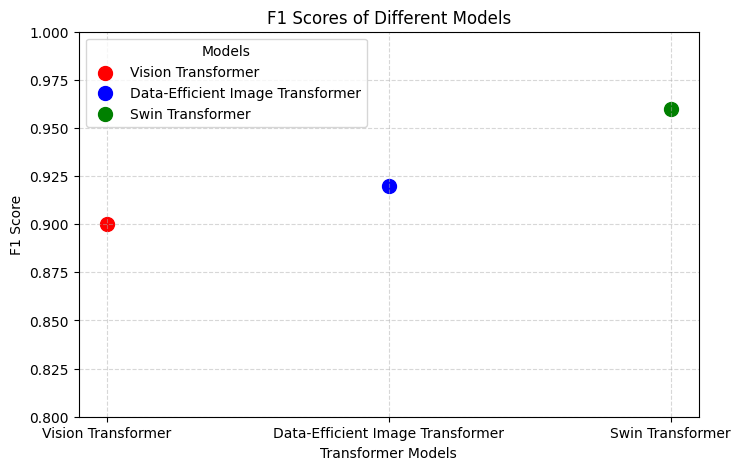

In [ ]:
import matplotlib.pyplot as plt

# Data
models = ['Vision Transformer','Data-Efficient Image Transformer', 'Swin Transformer']
f1_scores = [0.90, 0.92, 0.96]

# Assign a unique color to each model
colors = ['red', 'blue', 'green']

# Create scatter plot
plt.figure(figsize=(8, 5))
for i in range(len(models)):
    plt.scatter(models[i], f1_scores[i], color=colors[i], s=100, label=models[i])

# Labels and title
plt.title('F1 Scores of Different Models')
plt.xlabel('Transformer Models')
plt.ylabel('F1 Score')
plt.ylim(0.80, 1.0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Models')

# Show plot
plt.show()
